## Grid Search Hyperparameter optimization

This case study is all about using grid searches to identify the optimal parameters for a machine learning algorithm. To complere this case study, you'll use the Pima Indian diabetes dataset from Kaggle and KNN. Follow along with the preprocessing steps of this case study.

Load the necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# set random seed to try make this exercise and solutions reproducible (NB: this is just for teaching purpose and not something you would do in real life)
random_seed_number = 42
np.random.seed(random_seed_number)

#### Load the diabetes data

In [2]:
diabetes_data = pd.read_csv('data/diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**<font color='teal'> Start by reviewing the data info.</font>**

In [7]:
diabetes_data.shape

(768, 9)

In [6]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
diabetes_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**<font color='teal'> Apply the describe function to the data.</font>**

In [9]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**<font color='teal'> Currently, the missing values in the dataset are represented as zeros. Replace the zero values in the following columns ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] with nan .</font>**

In [10]:
# Columns where zero represents missing values
cols_with_zero_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN in those columns
diabetes_data[cols_with_zero_missing] = diabetes_data[cols_with_zero_missing].replace(0, np.nan)

# Verify the change
diabetes_data[cols_with_zero_missing].isnull().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

**<font color='teal'> Plot histograms of each column. </font>**

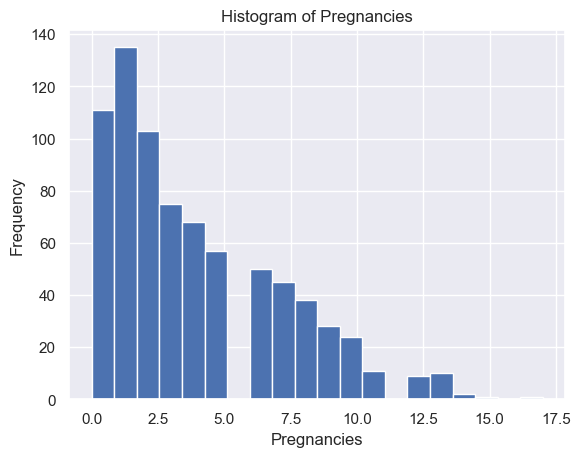

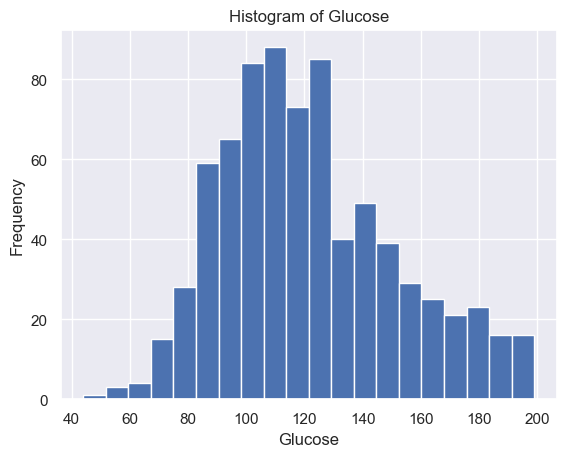

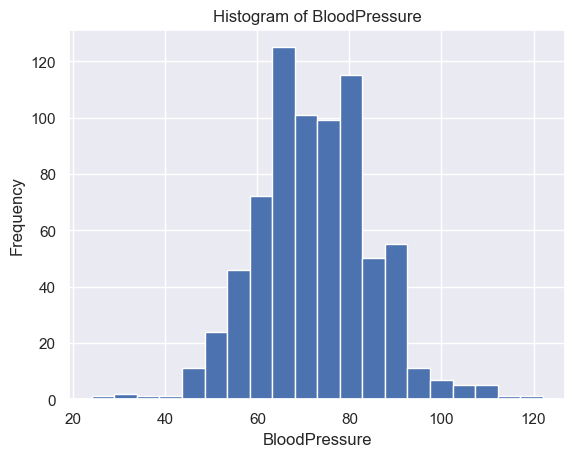

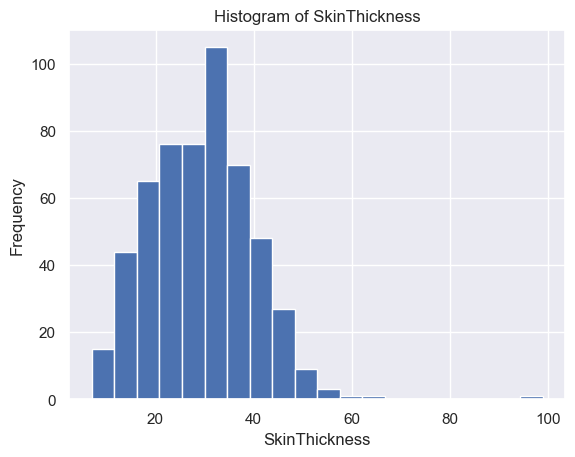

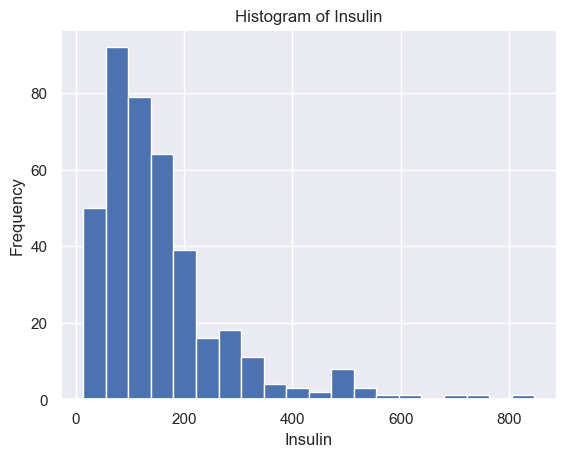

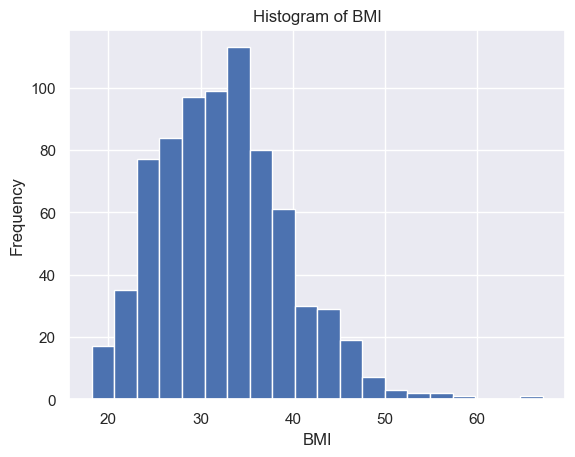

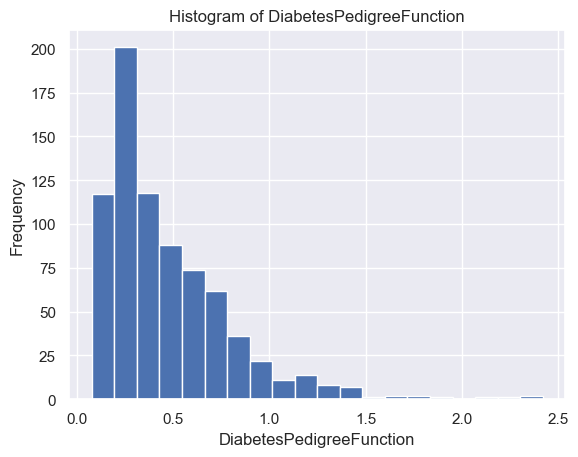

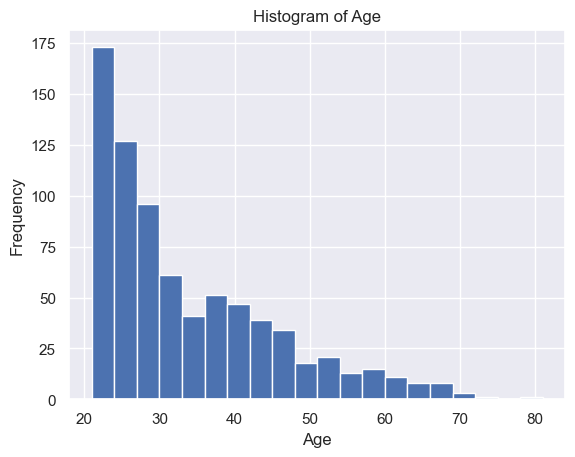

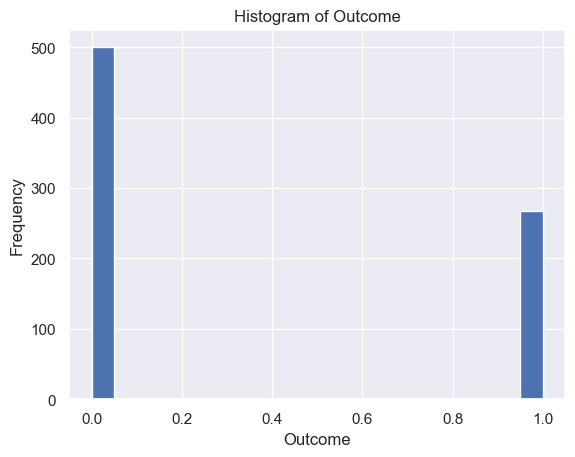

In [11]:
for column in diabetes_data.columns:
    plt.figure()
    diabetes_data[column].hist(bins=20)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

#### Replace the zeros with mean and median values.

In [12]:
diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean(), inplace = True)
diabetes_data['BloodPressure'].fillna(diabetes_data['BloodPressure'].mean(), inplace = True)
diabetes_data['SkinThickness'].fillna(diabetes_data['SkinThickness'].median(), inplace = True)
diabetes_data['Insulin'].fillna(diabetes_data['Insulin'].median(), inplace = True)
diabetes_data['BMI'].fillna(diabetes_data['BMI'].median(), inplace = True)

C:\TEmp\ipykernel_3004\2273347448.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean(), inplace = True)
C:\TEmp\ipykernel_3004\2273347448.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

**<font color='teal'> Plot histograms of each column after replacing nan. </font>**

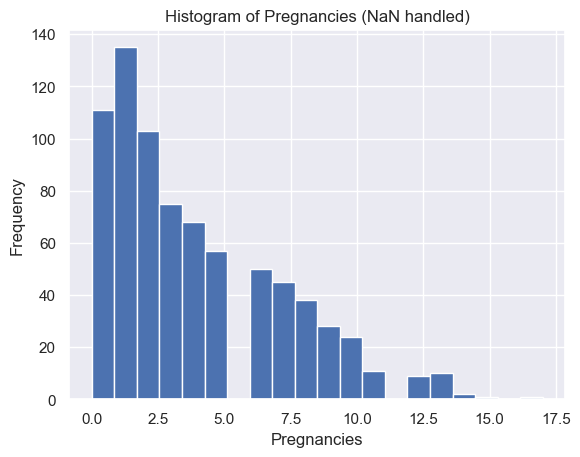

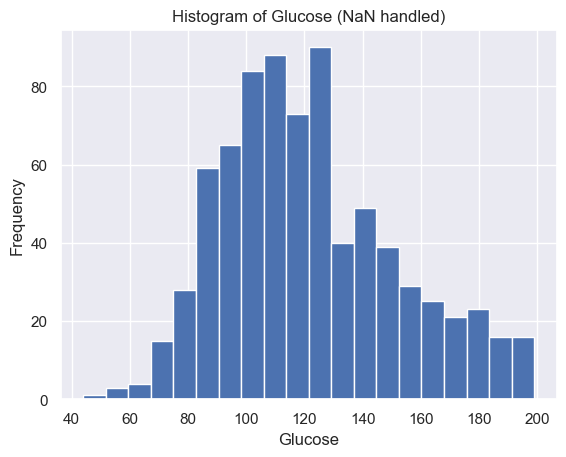

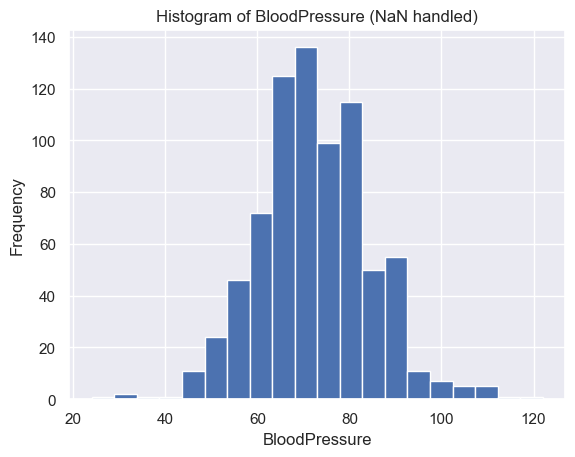

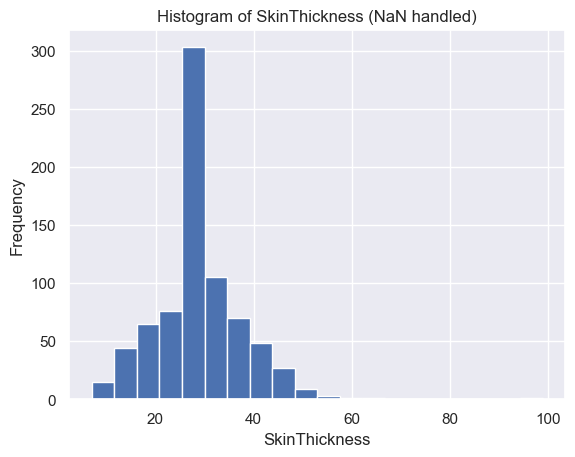

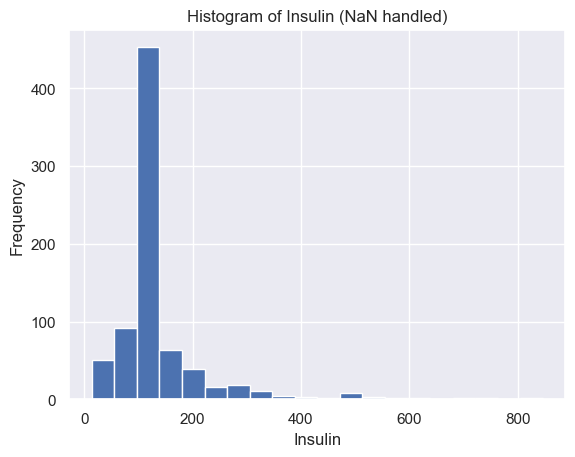

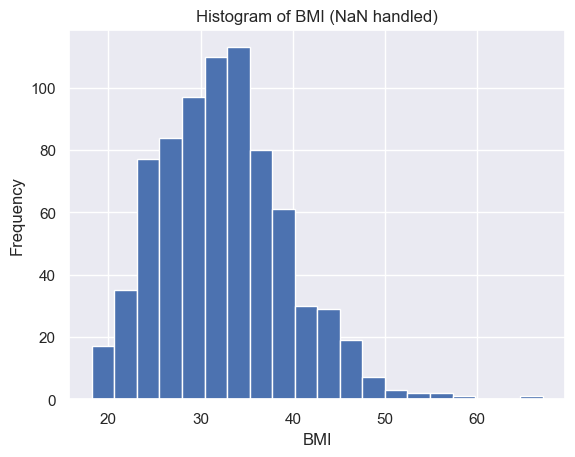

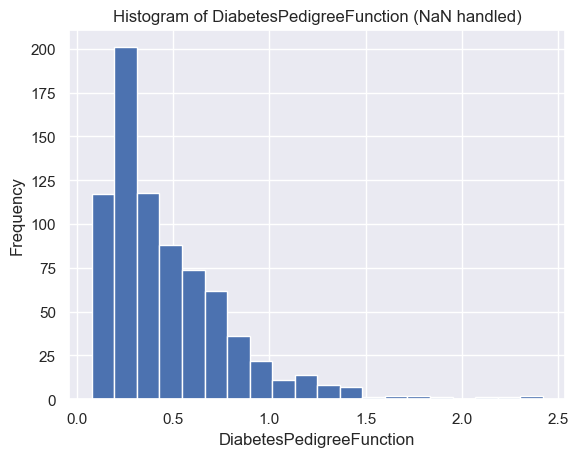

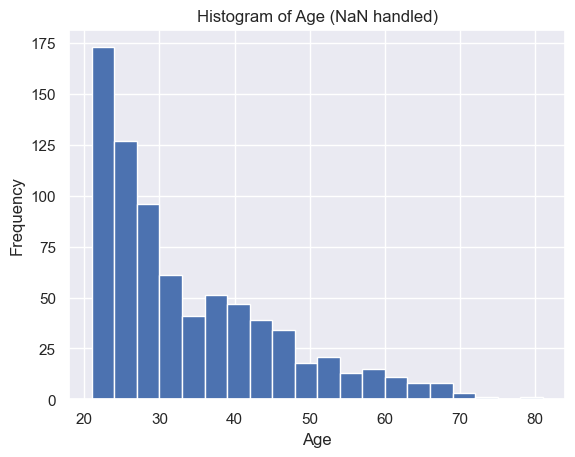

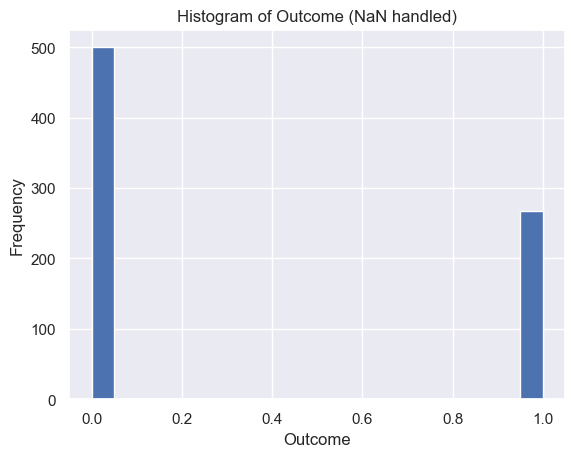

In [14]:
for column in diabetes_data.columns:
    plt.figure()
    diabetes_data[column].dropna().hist(bins=20)
    plt.title(f'Histogram of {column} (NaN handled)')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

#### Plot the correlation matrix heatmap

Correlation between various features


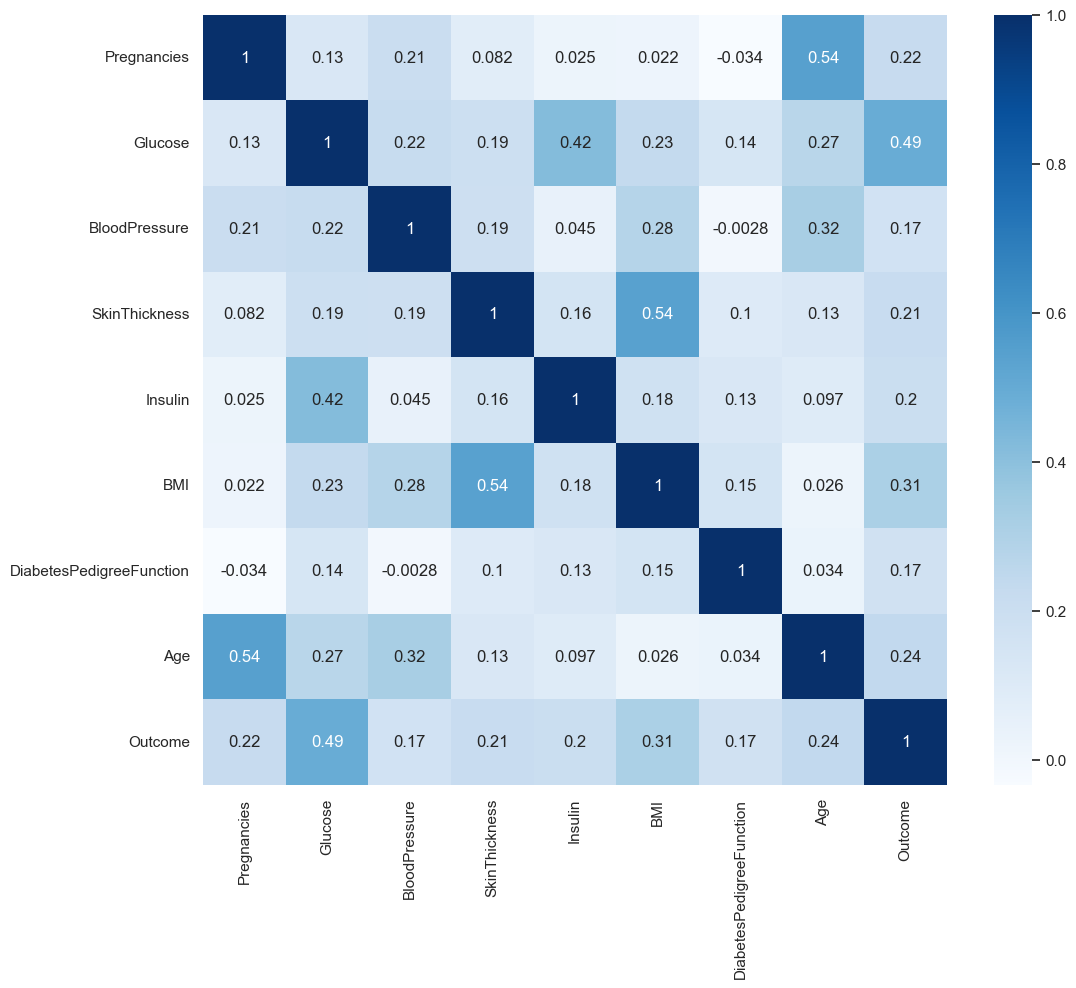

In [15]:
plt.figure(figsize=(12,10))
print('Correlation between various features')
p=sns.heatmap(diabetes_data.corr(), annot=True,cmap ='Blues')

**<font color='teal'> Define the `y` variable as the `Outcome` column.</font>**

In [16]:
# Define target variable
y = diabetes_data['Outcome']
# Define feature matrix
X = diabetes_data.drop(columns=['Outcome'])

**<font color='teal'> Create a 70/30 train and test split. </font>**

In [18]:
#Create 70/30 train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

**<font color='teal'> Using Sklearn, standarize the magnitude of the features by scaling the values. </font>**

Note: Don't forget to fit() your scaler on X_train and then use that fitted scaler to transform() X_test. This is to avoid data leakage while you standardize your data.

In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the fitted scaler to transform test data
X_test_scaled = scaler.transform(X_test)

#### Using a range of neighbor values of 1-10, apply the KNearestNeighbor classifier to classify the the data.

In [30]:
from sklearn.neighbors import KNeighborsClassifier


test_scores = []
train_scores = []

for i in range(1,10):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled,y_train)
    
    train_scores.append(knn.score(X_train_scaled,y_train))
    test_scores.append(knn.score(X_test_scaled,y_test))
 

**<font color='teal'> Print the train and test scores for each iteration.</font>**

In [31]:
# Print scores for this iteration
print(f"k={i}: Train Accuracy = {train_scores[-1]:.4f}, Test Accuracy = {test_scores[-1]:.4f}")

k=9: Train Accuracy = 0.8007, Test Accuracy = 0.7446


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the training dataset. </font>**

In [32]:
# Find the index of the maximum train score
max_train_index = train_scores.index(max(train_scores))

# Since k started from 1, add 1 to get the actual number of neighbors
best_k_train = max_train_index + 1

print(f"The number of neighbors with the highest training accuracy is: {best_k_train}")
print(f"Maximum training accuracy: {train_scores[max_train_index]:.4f}")

The number of neighbors with the highest training accuracy is: 1
Maximum training accuracy: 1.0000


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the testing dataset. </font>**

In [33]:
# Find the index of the maximum test score
max_test_index = test_scores.index(max(test_scores))

# Since k started from 1, add 1 to get the actual number of neighbors
best_k_test = max_test_index + 1

print(f"The number of neighbors with the highest test accuracy is: {best_k_test}")
print(f"Maximum test accuracy: {test_scores[max_test_index]:.4f}")

The number of neighbors with the highest test accuracy is: 8
Maximum test accuracy: 0.7489


Plot the train and test model performance by number of neighbors.

Text(0.5, 1.0, 'KNN: Train vs Test Accuracy for different k')

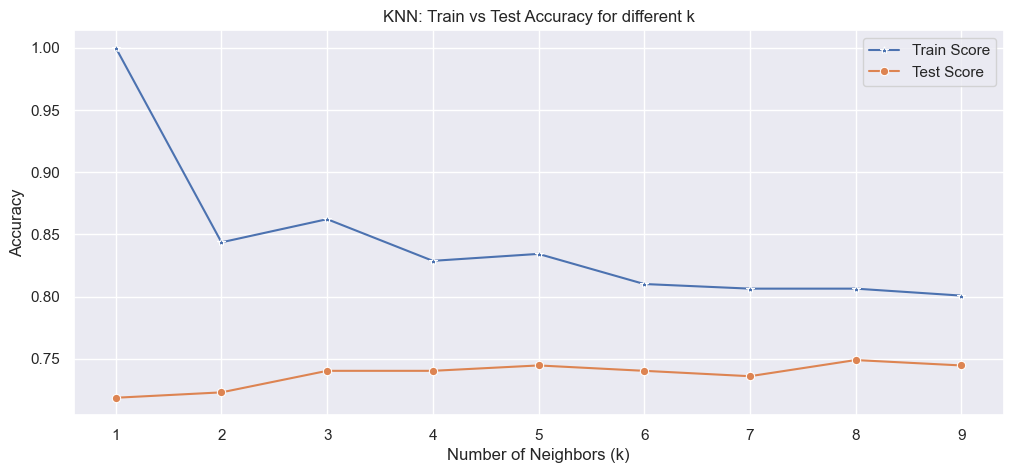

In [39]:
plt.figure(figsize=(12,5))
p = sns.lineplot(x=range(1,10),y=train_scores,marker='*',label='Train Score')
p = sns.lineplot(x=range(1,10),y=test_scores,marker='o',label='Test Score')
plt.xticks(k_values)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test Accuracy for different k')

**<font color='teal'> Fit and score the best number of neighbors based on the plot. </font>**

you can fit KNN with the optimal number of neighbors (the one giving the highest test accuracy)

In [40]:
from sklearn.neighbors import KNeighborsClassifier

# Optimal k from test accuracy
best_k = test_scores.index(max(test_scores)) + 1
print(f"Best number of neighbors based on test accuracy: {best_k}")

# Initialize and fit KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

# Evaluate on training and testing data
train_acc = knn_best.score(X_train_scaled, y_train)
test_acc = knn_best.score(X_test_scaled, y_test)

print(f"Train Accuracy with k={best_k}: {train_acc:.4f}")
print(f"Test Accuracy with k={best_k}: {test_acc:.4f}")

Best number of neighbors based on test accuracy: 8
Train Accuracy with k=8: 0.8063
Test Accuracy with k=8: 0.7489


In [42]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
pl = confusion_matrix(y_test,y_pred)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


**<font color='teal'> Plot the confusion matrix for the model fit above. </font>**

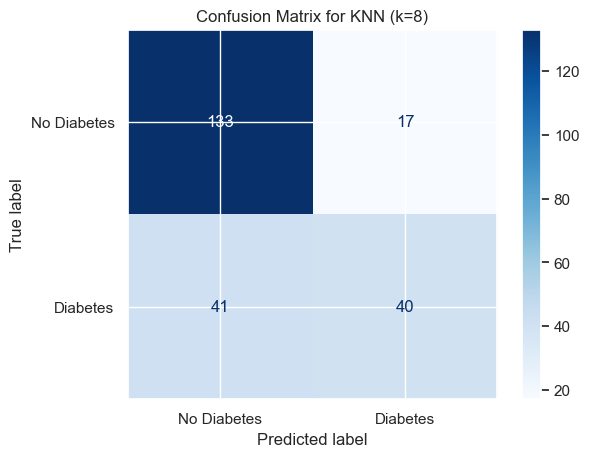

In [46]:
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for KNN (k={best_k})')
plt.show()


**<font color='teal'> Print the classification report </font>**

In [47]:
from sklearn.metrics import classification_report

# Predict on the test data
y_pred = knn_best.predict(X_test_scaled)

# Generate classification report
report = classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.76      0.89      0.82       150
    Diabetes       0.70      0.49      0.58        81

    accuracy                           0.75       231
   macro avg       0.73      0.69      0.70       231
weighted avg       0.74      0.75      0.74       231



#### In the case of the K nearest neighbors algorithm, the K parameter is one of the most important parameters affecting the model performance.  The model performance isn't horrible, but what if we didn't consider a wide enough range of values in our neighbors for the KNN? An alternative to fitting a loop of models is to use a grid search to identify the proper number. It is common practice to use a grid search method for all adjustable parameters in any type of machine learning algorithm. First, you define the grid — aka the range of values — to test in the parameter being optimized, and then compare the model outcome performance based on the different values in the grid.

#### Run the code in the next cell to see how to implement the grid search method for identifying the best parameter value for the n_neighbors parameter. Notice the param_grid is the range value to test and we apply cross validation with five folds to score each possible value of n_neighbors.

In [48]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

#### Print the best score and best parameter for n_neighbors.

In [49]:
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7526440879382056
Best Parameters: {'n_neighbors': 31}


Here you can see that the ideal number of n_neighbors for this model is 14 based on the grid search performed. 

**<font color='teal'> Now, following the KNN example, apply this grid search method to find the optimal number of estimators in a Randon Forest model.
</font>**

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Define the grid of parameters to search
param_grid = {
    'n_estimators': [10, 50, 100, 200, 300]  # You can adjust this range
}

# Set up GridSearchCV
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy', # Evaluate based on accuracy
    n_jobs=-1           # Use all processors
)

# Fit the GridSearch to the training data
rf_cv.fit(X_train_scaled, y_train)

# Print the best score and the optimal n_estimators
print("Best Score: " + str(rf_cv.best_score_))
print("Best Parameters: " + str(rf_cv.best_params_))

Best Score: 0.7598130841121495
Best Parameters: {'n_estimators': 100}


Optimal number of estimators: 100
Classification Report for Random Forest:

              precision    recall  f1-score   support

 No Diabetes       0.77      0.84      0.80       150
    Diabetes       0.64      0.53      0.58        81

    accuracy                           0.73       231
   macro avg       0.71      0.69      0.69       231
weighted avg       0.72      0.73      0.72       231



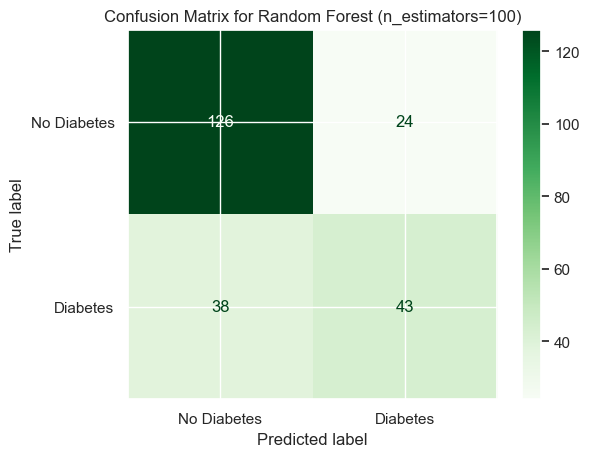

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Get the best n_estimators from GridSearchCV
best_n_estimators = rf_cv.best_params_['n_estimators']
print(f"Optimal number of estimators: {best_n_estimators}")

# Step 2: Fit the Random Forest with the best parameter
rf_best = RandomForestClassifier(n_estimators=best_n_estimators, random_state=42)
rf_best.fit(X_train_scaled, y_train)

# Step 3: Predict on the test data
y_pred_rf = rf_best.predict(X_test_scaled)

# Step 4: Print classification report
print("Classification Report for Random Forest:\n")
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

# Step 5: Plot confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Diabetes', 'Diabetes'])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title(f'Confusion Matrix for Random Forest (n_estimators={best_n_estimators})')
plt.show()

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define a function to compute metrics
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

# Compute metrics for KNN
metrics_knn = compute_metrics(y_test, knn_best.predict(X_test_scaled))

# Compute metrics for Random Forest
metrics_rf = compute_metrics(y_test, rf_best.predict(X_test_scaled))

# Combine results into a DataFrame for comparison
comparison_df = pd.DataFrame([metrics_knn, metrics_rf], index=['KNN', 'Random Forest'])
print("Model Comparison:\n")
print(comparison_df)

Model Comparison:

               Accuracy  Precision    Recall  F1-Score
KNN            0.748918   0.701754  0.493827  0.579710
Random Forest  0.731602   0.641791  0.530864  0.581081


Conclusion: Diabetes Prediction

In this project, we analyzed a dataset of diabetes patient records and developed predictive models to classify the presence of diabetes. The preprocessing phase included:

Identifying and replacing missing values (originally encoded as zeros) in clinical measurements such as Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI with NaN.

Standardizing the features using StandardScaler to ensure consistent magnitude across variables, which is critical for distance-based algorithms like KNN.

Splitting the dataset into a 70/30 train-test split, while stratifying to preserve the class distribution.

Two machine learning models were developed and evaluated: K-Nearest Neighbors (KNN) and Random Forest. For KNN, a grid search over k values identified the optimal number of neighbors. For Random Forest, a grid search over the number of estimators determined the best configuration. Both models were evaluated on the test set using accuracy, precision, recall, F1-score, and confusion matrices.

The model comparison revealed:

KNN achieved slightly higher accuracy (0.749) and precision (0.702), meaning it made fewer false-positive predictions.

Random Forest achieved slightly higher recall (0.531) and a marginally better F1-score (0.581), meaning it detected more true diabetes cases.

Given that the recall of the positive class (diabetes patients) is critical in a healthcare context to minimize missed diagnoses, Random Forest is the recommended model. It balances precision and recall effectively and provides robust predictions with interpretable results.

Overall, this project demonstrates the importance of data preprocessing, feature scaling, hyperparameter tuning, and model evaluation in building reliable predictive models for healthcare applications.